In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.distributions import Dirichlet

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
FEATURE_COLS = feature_cfg["feature_columns"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Must match notebook 06 / 08
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.1
DIRICHLET_CONC_MIN = 5.0
DIRICHLET_CONC_MAX = 200.0

COST_GRID = [0.0005, 0.001, 0.002, 0.005]

MODEL_DIR_COST_AWARE = f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y"
MODEL_DIR_NO_COST = f"{OUTPUTS_MODEL_DIR}/transformer_ppo_nocost_5y"

print("DEVICE:", DEVICE)
print("COST_GRID:", COST_GRID)
print("MODEL_DIR_COST_AWARE:", MODEL_DIR_COST_AWARE)
print("MODEL_DIR_NO_COST:", MODEL_DIR_NO_COST)

DEVICE: cpu
COST_GRID: [0.0005, 0.001, 0.002, 0.005]
MODEL_DIR_COST_AWARE: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y
MODEL_DIR_NO_COST: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_nocost_5y


In [5]:
# ============================================================
# CELL 04 — Load env-ready 5Y data
# ============================================================

env_ready = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

X_test = env_ready["X_test"].astype(np.float32)
y_test = env_ready["y_test"].astype(np.float32)
dates_test = env_ready["dates_test"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("dates_test:", dates_test.shape)

X_test: (251, 20, 5, 13)
y_test: (251, 5)
dates_test: (251,)


In [6]:
# ============================================================
# CELL 05 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.n_assets = self.X.shape[2]
        self.reset()

    def reset(self):
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(
            next_state=next_state,
            reward=float(reward),
            done=self.done,
            info=info,
        )

In [7]:
# ============================================================
# CELL 06 — Transformer model definition
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        l = x.size(1)
        return x + self.pe[:, :l, :]


class TransformerEncoderState(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.input_dim = n_assets * n_features
        self.input_proj = nn.Linear(self.input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=lookback + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.post = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        h = self.transformer(x)
        h_last = h[:, -1, :]
        h_last = self.post(h_last)
        return h_last


class TransformerActorCritic(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        conc_min: float,
        conc_max: float,
    ):
        super().__init__()

        self.n_assets = n_assets
        self.conc_min = conc_min
        self.conc_max = conc_max

        self.encoder = TransformerEncoderState(
            lookback=lookback,
            n_assets=n_assets,
            n_features=n_features,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
        )

        self.actor_logits = nn.Linear(d_model, n_assets)
        self.actor_concentration = nn.Linear(d_model, 1)
        self.critic = nn.Linear(d_model, 1)

    def _get_shared(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def get_policy_dist(self, x: torch.Tensor):
        h = self._get_shared(x)

        logits = self.actor_logits(h)
        mean_weights = torch.softmax(logits, dim=-1)

        raw_conc = self.actor_concentration(h)
        conc_scalar = torch.sigmoid(raw_conc)
        conc_scalar = self.conc_min + (self.conc_max - self.conc_min) * conc_scalar
        conc_scalar = conc_scalar.squeeze(-1)

        alpha = mean_weights * conc_scalar.unsqueeze(-1)
        alpha = torch.clamp(alpha, min=1e-4)

        dist = Dirichlet(alpha)
        return dist, mean_weights, alpha

    def act_deterministic(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        return mean_weights

In [8]:
# ============================================================
# CELL 07 — Load both trained models
# ============================================================

def build_transformer_model():
    return TransformerActorCritic(
        lookback=LOOKBACK,
        n_assets=len(ASSETS),
        n_features=len(FEATURE_COLS),
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        conc_min=DIRICHLET_CONC_MIN,
        conc_max=DIRICHLET_CONC_MAX,
    ).to(DEVICE)

cost_model = build_transformer_model()
nocost_model = build_transformer_model()

cost_ckpt = f"{MODEL_DIR_COST_AWARE}/best_model.pt"
nocost_ckpt = f"{MODEL_DIR_NO_COST}/best_model.pt"

assert os.path.exists(cost_ckpt), f"Missing file: {cost_ckpt}"
assert os.path.exists(nocost_ckpt), f"Missing file: {nocost_ckpt}"

cost_model.load_state_dict(torch.load(cost_ckpt, map_location=DEVICE))
nocost_model.load_state_dict(torch.load(nocost_ckpt, map_location=DEVICE))

cost_model.eval()
nocost_model.eval()

print("Loaded both transformer models successfully.")

Loaded both transformer models successfully.


In [9]:
# ============================================================
# CELL 08 — Evaluation helpers
# ============================================================

def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }


def evaluate_model_under_cost(model, model_name: str, transaction_cost: float):
    env = PortfolioEnv(
        X=X_test,
        y=y_test,
        dates=dates_test,
        transaction_cost=transaction_cost,
        reward_mode="cost_aware",
    )

    state = env.reset()
    rows = []

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            action_t = model.act_deterministic(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        row = {
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
            "model": model_name,
            "transaction_cost": transaction_cost,
        }

        for i, asset in enumerate(ASSETS):
            row[f"w_{asset}"] = float(result.info["weights"][i])

        rows.append(row)

        if result.done:
            break

        state = result.next_state

    df_rollout = pd.DataFrame(rows)
    metrics = compute_rollout_metrics(df_rollout)
    return df_rollout, metrics

In [10]:
# ============================================================
# CELL 09 — Run cost sensitivity experiment
# ============================================================

sensitivity_rows = []
sensitivity_rollouts = {}

for model_name, model_obj in [
    ("Transformer_CostAwareTrain", cost_model),
    ("Transformer_NoCostTrain", nocost_model),
]:
    sensitivity_rollouts[model_name] = {}

    for tc in COST_GRID:
        rollout_df, metrics = evaluate_model_under_cost(
            model=model_obj,
            model_name=model_name,
            transaction_cost=tc,
        )

        sensitivity_rollouts[model_name][tc] = rollout_df
        sensitivity_rows.append({
            "model": model_name,
            "transaction_cost": tc,
            **metrics,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

,model,transaction_cost,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,Transformer_CostAwareTrain,0.0005,251,1.227644,0.227644,0.000974,0.009823,1.574676,-0.102981,0.216549,0.027177,0.000108
1,Transformer_CostAwareTrain,0.0010,251,1.194722,0.194722,0.000974,0.009823,1.574676,-0.105164,0.216549,0.054354,0.000217
2,Transformer_CostAwareTrain,0.0020,251,1.131488,0.131488,0.000974,0.009823,1.574676,-0.109514,0.216549,0.108708,0.000433
3,Transformer_CostAwareTrain,0.0050,251,0.961068,-0.038932,0.000974,0.009823,1.574676,-0.122451,0.216549,0.271769,0.001083
4,Transformer_NoCostTrain,0.0005,251,1.217832,0.217832,0.000871,0.007958,1.738375,-0.076781,0.108494,0.013616,0.000054
5,Transformer_NoCostTrain,0.0010,251,1.201361,0.201361,0.000871,0.007958,1.738375,-0.077457,0.108494,0.027232,0.000108
6,Transformer_NoCostTrain,0.0020,251,1.169080,0.169080,0.000871,0.007958,1.738375,-0.078807,0.108494,0.054464,0.000217
7,Transformer_NoCostTrain,0.0050,251,1.077322,0.077322,0.000871,0.007958,1.738375,-0.082848,0.108494,0.136160,0.000542


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=sensitivity_df)

https://docs.google.com/spreadsheets/d/1MyqdH9YLoN6o9dPtUHTpyK-ReVuR18Bi7Ox9eNlT8bE/edit#gid=0


In [12]:
# ============================================================
# CELL 10 — Pivot tables for sensitivity analysis
# ============================================================

pivot_cumret = sensitivity_df.pivot(index="transaction_cost", columns="model", values="cumulative_return")
pivot_sharpe = sensitivity_df.pivot(index="transaction_cost", columns="model", values="sharpe_approx")
pivot_turnover = sensitivity_df.pivot(index="transaction_cost", columns="model", values="avg_turnover")
pivot_trading_cost = sensitivity_df.pivot(index="transaction_cost", columns="model", values="total_trading_cost")

display(pivot_cumret)
display(pivot_sharpe)
display(pivot_turnover)
display(pivot_trading_cost)

model,Transformer_CostAwareTrain,Transformer_NoCostTrain
transaction_cost,,
0.0005,0.227644,0.217832
0.0010,0.194722,0.201361
0.0020,0.131488,0.169080
0.0050,-0.038932,0.077322


model,Transformer_CostAwareTrain,Transformer_NoCostTrain
transaction_cost,,
0.0005,1.574676,1.738375
0.0010,1.574676,1.738375
0.0020,1.574676,1.738375
0.0050,1.574676,1.738375


model,Transformer_CostAwareTrain,Transformer_NoCostTrain
transaction_cost,,
0.0005,0.216549,0.108494
0.0010,0.216549,0.108494
0.0020,0.216549,0.108494
0.0050,0.216549,0.108494


model,Transformer_CostAwareTrain,Transformer_NoCostTrain
transaction_cost,,
0.0005,0.027177,0.013616
0.0010,0.054354,0.027232
0.0020,0.108708,0.054464
0.0050,0.271769,0.136160


In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_trading_cost)

https://docs.google.com/spreadsheets/d/1Tiz2XYjHQQBxfwd1qOuZZHGNDdWIyM_FCCjmhNs-0Pw/edit#gid=0


In [15]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_turnover)

https://docs.google.com/spreadsheets/d/1t-UzbXG3yhKuzXEJR6R9Vh1wPYmtZEo2H8yVM92EtHo/edit#gid=0


In [14]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_sharpe)

https://docs.google.com/spreadsheets/d/1EAHcH5LUkuUx76GoFmJ92lu-6SDOq4pbw_xkNs5a6ks/edit#gid=0


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_cumret)

https://docs.google.com/spreadsheets/d/1NxL9TbGcU48-jfqBEOm3hNwwOlngzLFgyxREipHQBDs/edit#gid=0


In [17]:
# ============================================================
# CELL 11 — Build compact comparison table
# ============================================================

compact_table = sensitivity_df[[
    "model",
    "transaction_cost",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

compact_table = compact_table.sort_values(["transaction_cost", "cumulative_return"], ascending=[True, False]).reset_index(drop=True)
display(compact_table)

,model,transaction_cost,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,Transformer_CostAwareTrain,0.0005,0.227644,1.574676,-0.102981,0.216549,0.027177
1,Transformer_NoCostTrain,0.0005,0.217832,1.738375,-0.076781,0.108494,0.013616
2,Transformer_NoCostTrain,0.0010,0.201361,1.738375,-0.077457,0.108494,0.027232
3,Transformer_CostAwareTrain,0.0010,0.194722,1.574676,-0.105164,0.216549,0.054354
4,Transformer_NoCostTrain,0.0020,0.169080,1.738375,-0.078807,0.108494,0.054464
5,Transformer_CostAwareTrain,0.0020,0.131488,1.574676,-0.109514,0.216549,0.108708
6,Transformer_NoCostTrain,0.0050,0.077322,1.738375,-0.082848,0.108494,0.136160
7,Transformer_CostAwareTrain,0.0050,-0.038932,1.574676,-0.122451,0.216549,0.271769


In [18]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=compact_table)

https://docs.google.com/spreadsheets/d/1lB6_FWcyrkqf_X44m16szUbORHSyo97zKQAiKSALgfM/edit#gid=0


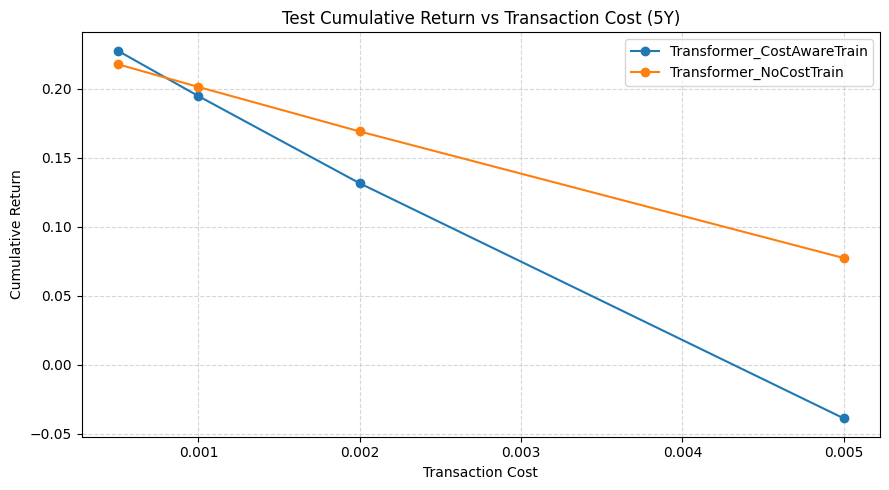

In [19]:
# ============================================================
# CELL 12 — Plot cumulative return sensitivity
# ============================================================

plt.figure(figsize=(9, 5))

for model_name in ["Transformer_CostAwareTrain", "Transformer_NoCostTrain"]:
    part = sensitivity_df[sensitivity_df["model"] == model_name].sort_values("transaction_cost")
    plt.plot(part["transaction_cost"], part["cumulative_return"], marker="o", label=model_name)

plt.title("Test Cumulative Return vs Transaction Cost (5Y)")
plt.xlabel("Transaction Cost")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

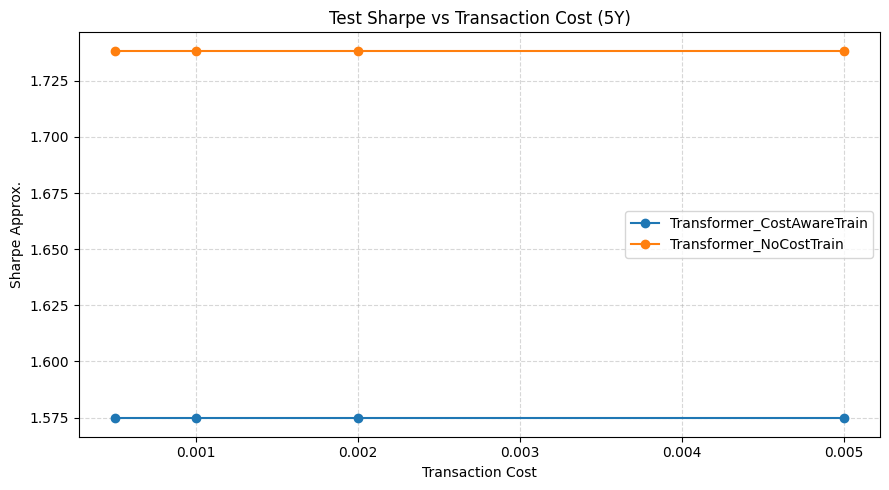

In [20]:
# ============================================================
# CELL 13 — Plot Sharpe sensitivity
# ============================================================

plt.figure(figsize=(9, 5))

for model_name in ["Transformer_CostAwareTrain", "Transformer_NoCostTrain"]:
    part = sensitivity_df[sensitivity_df["model"] == model_name].sort_values("transaction_cost")
    plt.plot(part["transaction_cost"], part["sharpe_approx"], marker="o", label=model_name)

plt.title("Test Sharpe vs Transaction Cost (5Y)")
plt.xlabel("Transaction Cost")
plt.ylabel("Sharpe Approx.")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

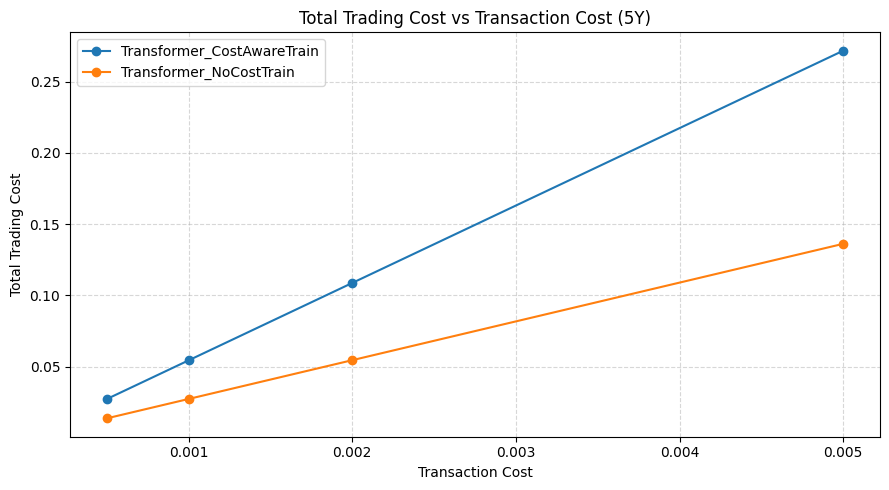

In [21]:
# ============================================================
# CELL 14 — Plot total trading cost sensitivity
# ============================================================

plt.figure(figsize=(9, 5))

for model_name in ["Transformer_CostAwareTrain", "Transformer_NoCostTrain"]:
    part = sensitivity_df[sensitivity_df["model"] == model_name].sort_values("transaction_cost")
    plt.plot(part["transaction_cost"], part["total_trading_cost"], marker="o", label=model_name)

plt.title("Total Trading Cost vs Transaction Cost (5Y)")
plt.xlabel("Transaction Cost")
plt.ylabel("Total Trading Cost")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

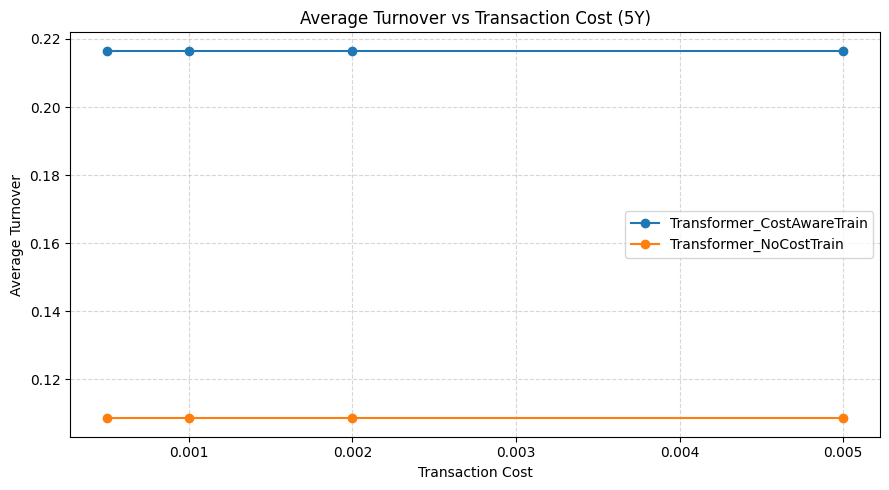

In [22]:
# ============================================================
# CELL 15 — Plot turnover sensitivity
# ============================================================

plt.figure(figsize=(9, 5))

for model_name in ["Transformer_CostAwareTrain", "Transformer_NoCostTrain"]:
    part = sensitivity_df[sensitivity_df["model"] == model_name].sort_values("transaction_cost")
    plt.plot(part["transaction_cost"], part["avg_turnover"], marker="o", label=model_name)

plt.title("Average Turnover vs Transaction Cost (5Y)")
plt.xlabel("Transaction Cost")
plt.ylabel("Average Turnover")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

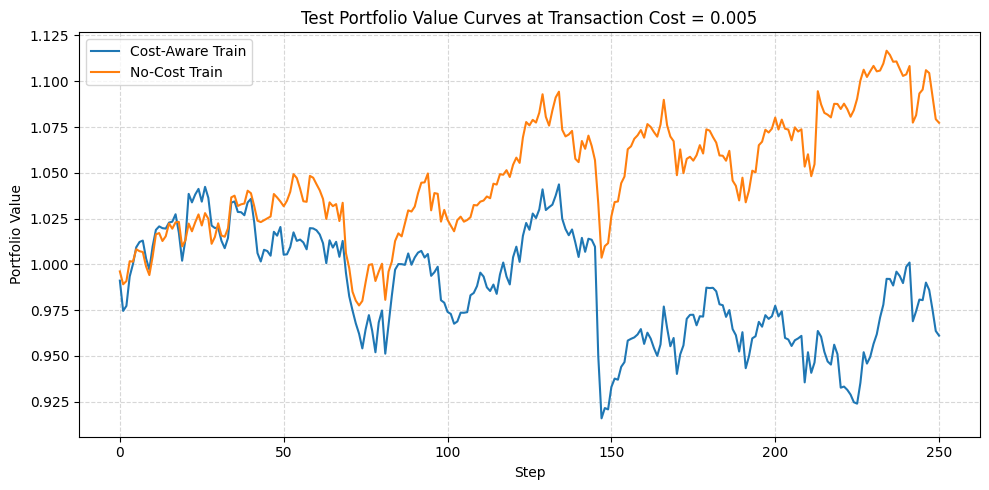

In [23]:
# ============================================================
# CELL 16 — Plot example portfolio value curves at highest cost
# ============================================================

tc = max(COST_GRID)

plt.figure(figsize=(10, 5))
plt.plot(
    sensitivity_rollouts["Transformer_CostAwareTrain"][tc]["portfolio_value"].values,
    label="Cost-Aware Train"
)
plt.plot(
    sensitivity_rollouts["Transformer_NoCostTrain"][tc]["portfolio_value"].values,
    label="No-Cost Train"
)
plt.title(f"Test Portfolio Value Curves at Transaction Cost = {tc}")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 17 — Save outputs
# ============================================================

sensitivity_df.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_5y.csv", index=False)
compact_table.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_compact_5y.csv", index=False)

pivot_cumret.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_pivot_cumret_5y.csv")
pivot_sharpe.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_pivot_sharpe_5y.csv")
pivot_turnover.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_pivot_turnover_5y.csv")
pivot_trading_cost.to_csv(f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_pivot_trading_cost_5y.csv")

print("Saved RQ2 cost sensitivity outputs.")

Saved RQ2 cost sensitivity outputs.


In [25]:
# ============================================================
# CELL 18 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_5y.csv",
    f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_compact_5y.csv",
    f"{OUTPUTS_REWARD_DIR}/rq2_cost_sensitivity_pivot_cumret_5y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

assert len(sensitivity_df) == 2 * len(COST_GRID)

print("All RQ2 cost sensitivity notebook checks passed.")

All RQ2 cost sensitivity notebook checks passed.
